In [1]:
import anndata as ad

In [3]:
import zarr
import scanpy as sc

In [24]:
z1 = zarr.open_group('/home/workspace/megazarr/megazarr_v1.0.zarr')

In [25]:
adata = ad.AnnData(
    obs = ad.io.read_elem(z1["obs"]),
    var = ad.io.read_elem(z1["var"]),
    obsm = ad.io.read_elem(z1["obsm"])
)

In [26]:
sc.pp.subsample(adata, n_obs=3_000_000, random_state=42)
print(adata)

AnnData object with n_obs × n_vars = 3000000 × 33538
    obs: 'original_barcodes', 'cell_name', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'n_reads', 'n_umis', 'n_genes', 'AIFI_L1', 'AIFI_L2', 'AIFI_L3', 'AIFI_L4', 'cohort.cohortGuid', 'subject.subjectGuid', 'sample.sampleKitGuid', 'pipeline.fileGuid', 'specimen.specimenGuid', 'leiden'
    obsm: 'X_umap'


In [ ]:
candidate_cols = ["AIFI_L1", "cohort.cohortGuid", "sample.sampleKitGuid", "subject.subjectGuid"] #Can add other obs columns here for batch effect checks.

sc.pl.umap(adata, color=candidate_cols, size=2)#, legend_loc="none")

/tmp/ipykernel_56477/603562122.py:1: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(


/tmp/ipykernel_56477/603562122.py:12: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


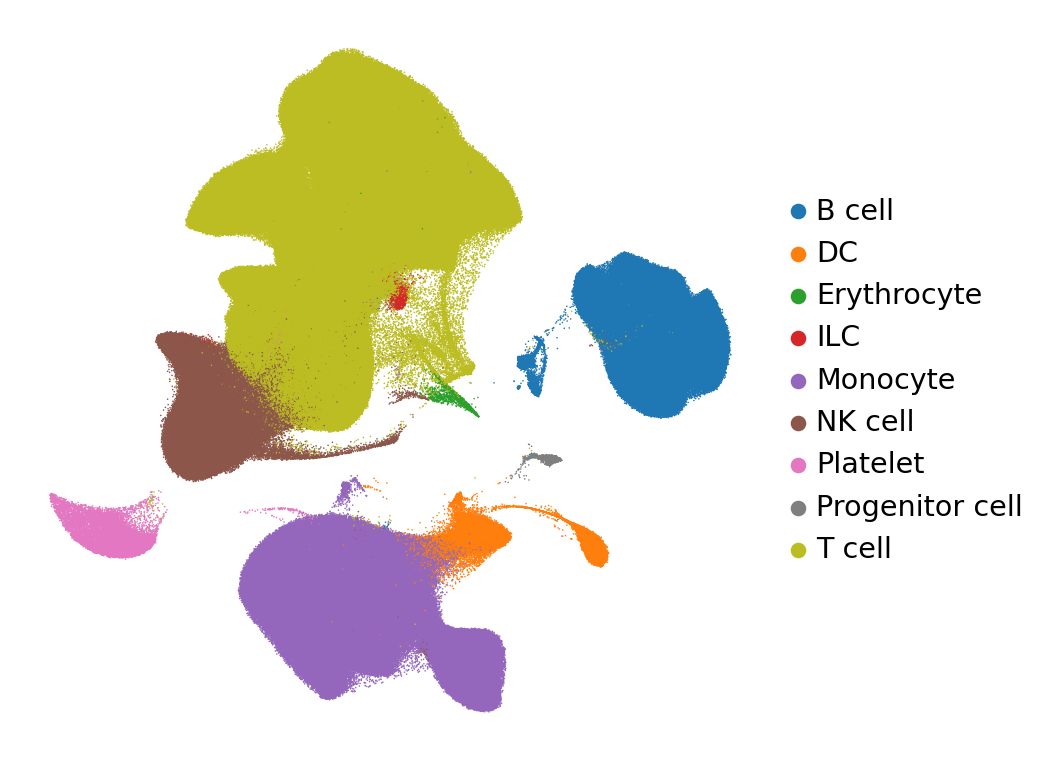

In [35]:
sc.settings.set_figure_params(
    dpi=80,
    facecolor='white',
    frameon=False,
    fontsize=14,
    dpi_save=200,
    figsize=(6,6),
    format='png'
)


sc.pl.umap(
    adata,
    color=['AIFI_L1'], 
    title = '',
    #palette=l2_cmap,
    size=2,
    save='megazarr_celltypes.png'
)

/tmp/ipykernel_56477/413185442.py:1: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(


/tmp/ipykernel_56477/413185442.py:11: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


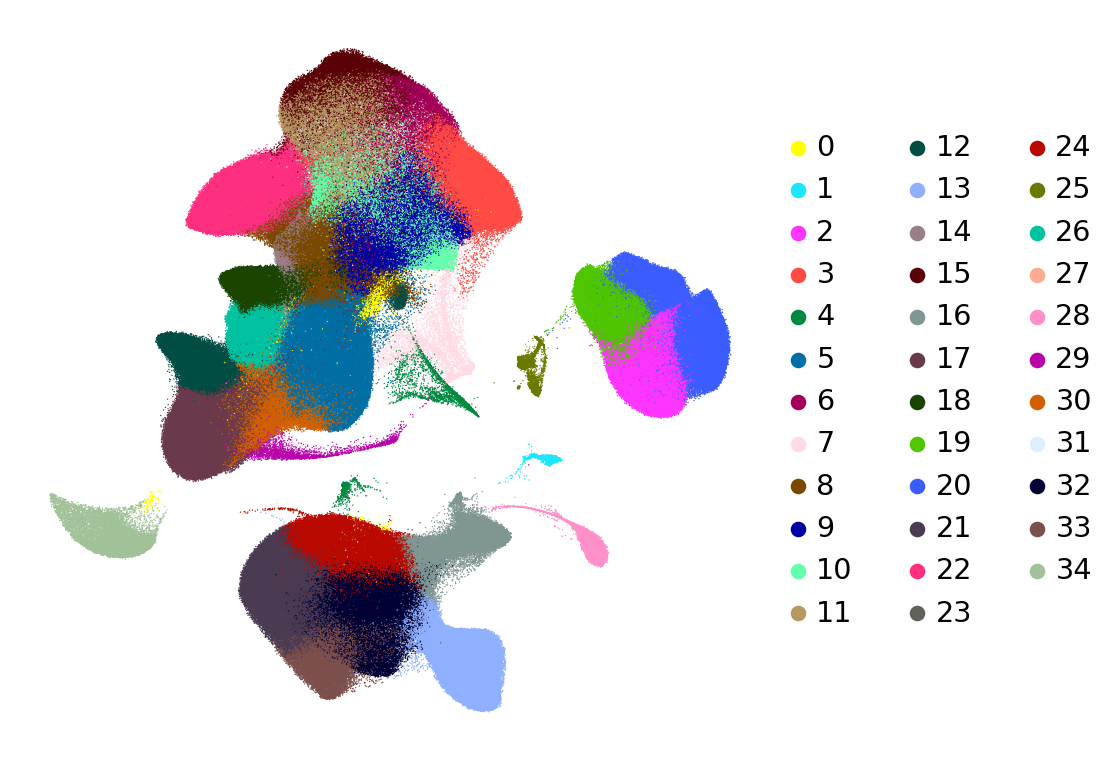

In [33]:
sc.settings.set_figure_params(
    dpi=80,
    facecolor='white',
    frameon=False,
    fontsize=14,
    dpi_save=200,
    figsize=(6,6),
    format='png'
)

sc.pl.umap(
    adata,
    color=['leiden'], 
    title = '',
    size=1.5,
    save='megazarr_leiden.png'
)

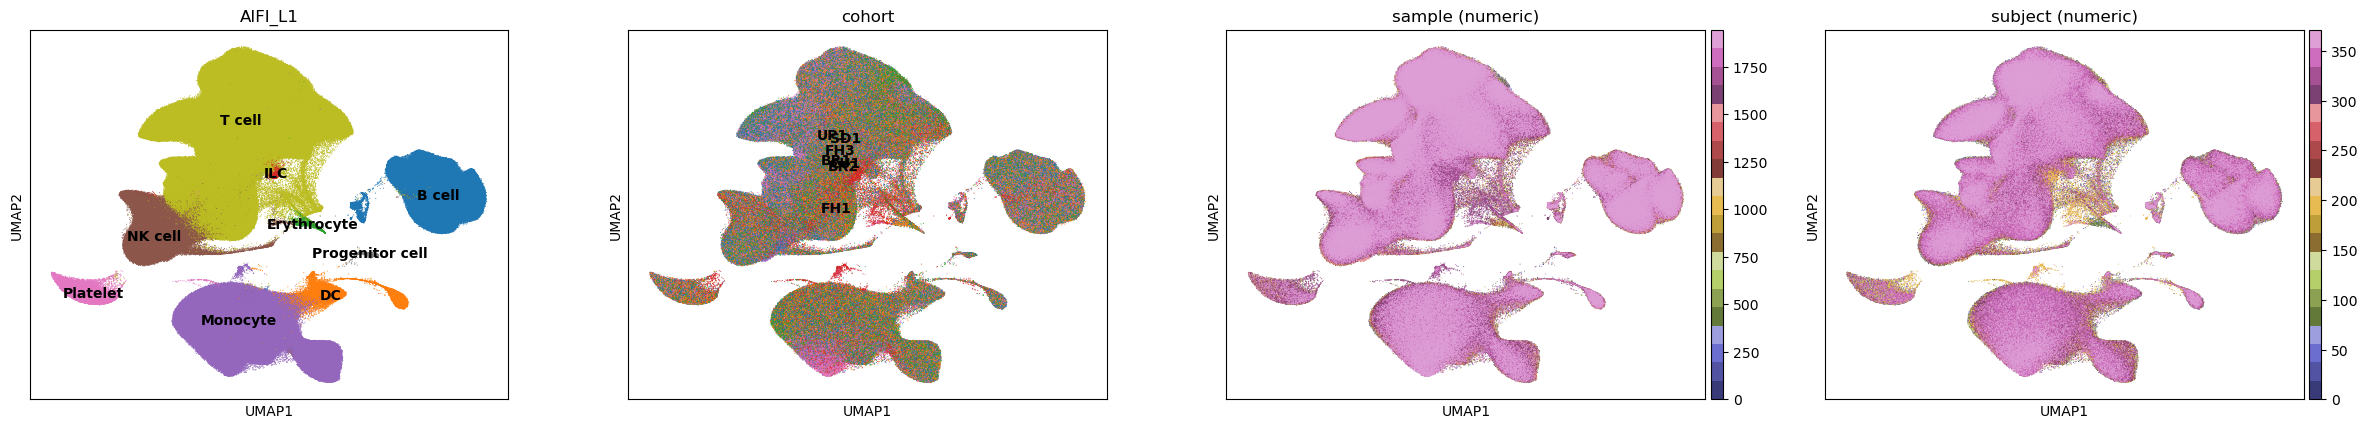

In [28]:

# Option 1: Continuous colormap for high-cardinality columns
# Converts each category to a numeric code so scanpy's 102-color limit doesn't apply.
# Good for seeing whether samples/subjects cluster — but you can't identify which is which.
high_card_cols = ["sample.sampleKitGuid", "subject.subjectGuid"]
for col in high_card_cols:
    adata.obs[f"{col}_code"] = adata.obs[col].astype("category").cat.codes.astype(float)

sc.pl.umap(
    adata,
    color=["AIFI_L1", "cohort.cohortGuid"] + [f"{c}_code" for c in high_card_cols],
    color_map="tab20b",
    size=2,
    legend_loc="on data",
    title=["AIFI_L1", "cohort", "sample (numeric)", "subject (numeric)"],
)
